
## The Bayesian Modeling Framework: A Paradigm Shift from Traditional Machine Learning

Bayesian modelling approaches are not very popular among the machine learning community. And unsurprisingly so. Most machine learning practitioners come from a computer science background and are not very well versed or not interested in statistical learning. However, these approaches can be very useful, specifically for solving certain types of problems. 


## Problem Statement
Let's think of a problem statement where bayesian modelling approach would be a good solution. 

Imagine you're working for a game development platform and you want to understand your users better so you can improve your revenue from game/application installs. You have many different kind of games for different app versions for different mobile operating systems, different markets and geographies, etc that you're operating in. Your marketing team wants you to provide them with a list of potential users to target. There's a lot of variables to look at and you want to predict the revenue generated from these apps and optimise revenue for the company. 

You start at the obvious place i.e the data. Once you start analyzing the data to understand user trends to answer business questions, you realise that for some customers you don't have enough data to make any reasonable predictions. Your standard machine learning model predictions are way off in certain markets. You notice that certain markets like Asia have some regulatory constraints that prohibits installing some apps or there's special business conditions. How do you encode this knowledge into your model? Having a rules-based logic with a bunch of if-then conditions is one solution but not a good, scalable one. 

The end users also want the model to be interpretable and simple for the marketing team who don't have any ML knowledge. How do you strike a balance between model's predictive capacity and model complexity and interprability? How do you build a model that still gives superior predictions but is still interpretable, explainable? How do you measure the uncertainty in your predictions? 

While exploring the data, you also notice that there's a clear hierarchy of the different mobile operating systems like android or ios, app versions, etc. Not all relationships are linear - they can be hierarchical as well and typically traditional machine learning approaches don't perform well in capturing these relationships well enough. How can you capture this hierarchical relationship without any loss of information and encode the business rules around them effectively? 

All these situations described above can be mitigated in the bayesian modelling framework more effectively than throwing compute and data-hungry, complex deep learning architectures at these problems. The bayesian framework applied to this problem provides better and more reliable predictions while meeting all the business requirements of simplicity, explainability, and quantifying uncertainty of predictions. It also works well with relatively small datasets and the quality of predictions need not suffer due to lack of data. 

## The foundation - Bayes Theorem

Bayesian modeling represents a fundamentally different approach from traditional machine learning, in that it treats parameters, predictions, and model structures as probability distributions rather than point estimates. At its core lies the  **Bayes' theorem**, which provides the mathematical foundation for updating beliefs in light of new evidence or data:

$$P(\theta | D) = \frac{P(D | \theta) \times P(\theta)}{P(D)}$$

Where:

- **P(D|θ)** is the **likelihood** - how probable our observed data is given different parameter values i.e the evidence or supporting actual data. For example, let's say, you have a probabilistic model to predict revenue from app installs, this refers to the actual historical revenue data you've gathered over the years for your apps. 
- **P(θ)** is the **prior distribution** - our initial beliefs about parameters before seeing data, this is what enables us to encode any prior information you might have from the business into your model. For example, let's say, you have a probabilistic model to predict revenue from app installs and covid hits, and all the historical data distributions suddenly change dramatically. Your standard ML model suddenly breaks down since the past data is not a good indicator for predicting the future anymore. But in a probabilistic model. you can encode this information and guide your model to rely more on the prior information being passed to the model than the past historical data. 
- **P(D)** is the **marginal likelihood** - the total probability of observing the data (normalizing constant)
- **P(θ|D)** is the **posterior distribution** - our updated beliefs about parameters θ after observing data D 

This equation encapsulates the Bayesian learning process: **Prior beliefs + New Evidence / Data = Updated beliefs**.

For the problem discussed above, the bayesian model starts with a prior belief of the real world and updates that belief as it sees new data or evidence coming into the model. That's exactly how we function in our daily lives in the probabilistic world that we live in. 

In a real-world scenario, let's say your business led you to believe that your customers in Asia install a particular version of the app only. However, the data suggests otherwise and the data tells you that the customers in Asia display a preference for a different version of the app. What do you do - stick to your belief or update your belief as you get more information? Naturally, you'd update your belief depending on the change in the situation. If you see data from just a handful of customers only, you might go with what the business tells you. However, once you see data from over 100 or 1000 customers showing preference for a different app version, you'd be more inclined to update your belief. That's exactly how the bayesian approach models the real world. 

### Key Differences from Traditional Machine Learning

**Traditional ML Approach (Frequentist)**:

- Treats parameters as fixed point estimates without uncertainty quantification
- Seeks single "best" parameter estimates (e.g., maximum likelihood estimation)
- Confidence intervals represent sampling variability, not parameter uncertainty
- No systematic way to incorporate prior knowledge

**Bayesian Approach**:

- Treats parameters as random variables with probability distributions
- Provides full posterior distributions over parameters
- Credible intervals directly represent parameter uncertainty
- Systematically incorporates prior knowledge through prior distributions
- Predictions include uncertainty through posterior predictive distributions

For example, in traditional linear regression, we estimate β as a point estimate. In Bayesian regression, we get a full distribution P(β|D) that quantifies our uncertainty about the true parameter values.



## Advantages of the Bayesian Approach

### 1. Full Probability Distributions Instead of Point Estimates

Traditional ML provides point predictions: "Team A will score 2.3 goals." 

Bayesian modeling provides **posterior predictive distributions**: "Team A will score 0-1 goals with 40% probability, 2-3 goals with 45% probability, 4+ goals with 15% probability."


### 2. Incorporating Prior Information: The Cold Start Solution

One of Bayesian modeling's most powerful features is its ability to systematically incorporate prior knowledge through prior distributions. This proves invaluable in **cold start scenarios** where data is scarce or unavailable.

**Business Example**: When launching a new product with no historical sales data, traditional ML methods fail completely. Bayesian approaches allow you to encode business intuition:

- Expert beliefs about market size
- Analogies to similar products
- Industry benchmarks and domain knowledge

As new data arrives, the model automatically balances prior beliefs with empirical evidence. Initially, predictions rely heavily on priors, but as data accumulates, the likelihood dominates and the model becomes increasingly data-driven, converging to the truth or actual distribution with increasing data.

**Mathematical Insight**: The posterior mean in conjugate models demonstrates this balance:
$$\text{Posterior Mean} = \lambda \times \text{Prior Mean} + (1-\lambda) \times \text{Data Mean}$$

Where λ represents the relative weight given to prior vs. data, automatically determined by the strength of prior beliefs and amount of observed data.

Bayesian methods possess excellent **asymptotic properties**. As sample size increases, posterior distributions concentrate around true parameter values regardless of prior specification (assuming the prior assigns positive probability to the truth).

This also implies,

- Poor prior choices become less influential with more data
- The model "learns" the true underlying patterns
- Uncertainty decreases systematically as evidence or data accumulates

This proves to be one of the most crucial advantages of the bayesian framework as demonstrated in the example below. 



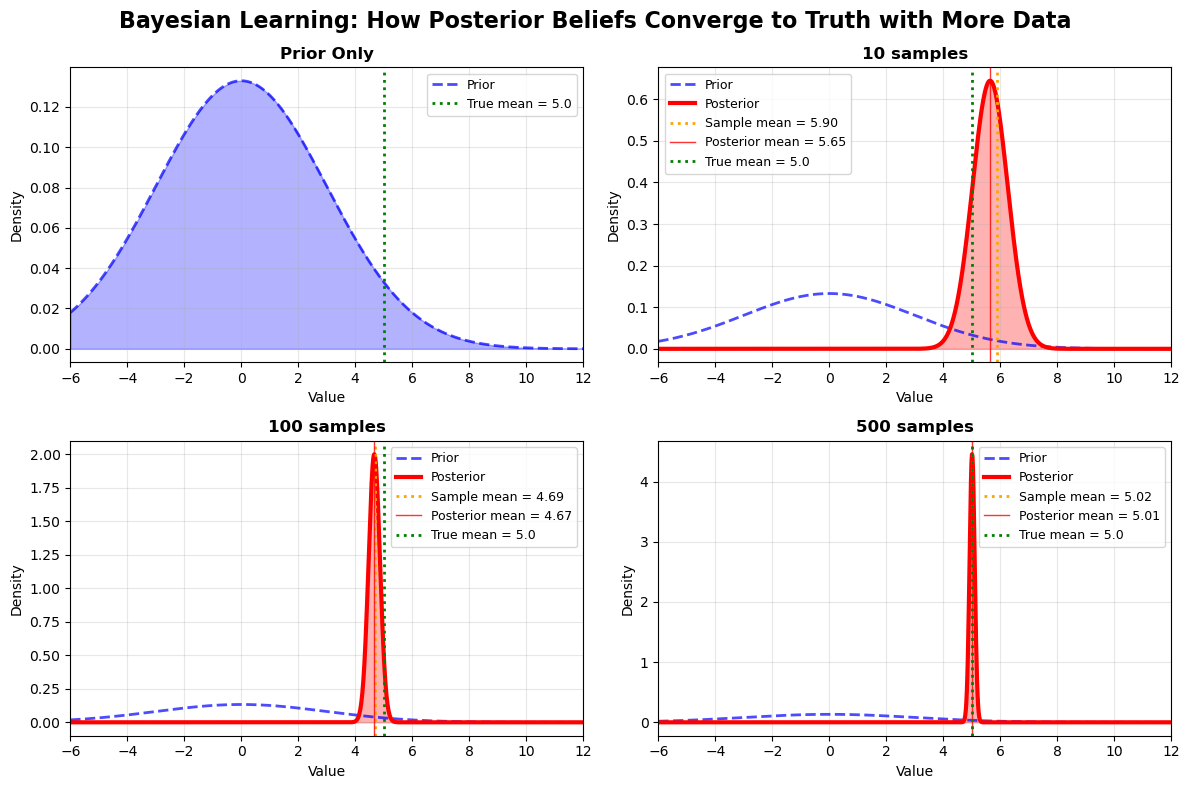

In [1]:
# Run the visualization
from lib.visualizations import plot_bayesian_prior_posterior
plot_bayesian_prior_posterior()

This simple visualization above perfectly demonstrates this: starting with a prior far from the truth, the posterior progressively moves toward the true parameters as sample size increases from 10 to 100 to 500 observations.

### 3. Uncertainty Quantification

Bayesian methods provide uncertainty about model parameters, predictions and this provides a basis for understanding prediction confidence and hence better risk management and decision making by incorporating uncertainty in optimal stategies. 

**Credible intervals** have direct probabilistic interpretation: "There's a 95% probability the true parameter lies in this interval" (unlike frequentist confidence intervals, which have more complex interpretations).

In the sports example illustration below, modelling the win probability of a game, we can see that the posterior mean converges to the true probability with increasing number of games while the confidence interval shrinks at the same time with increase in number of games. Another way of looking at it, is the reduction in uncertainty with more data. 

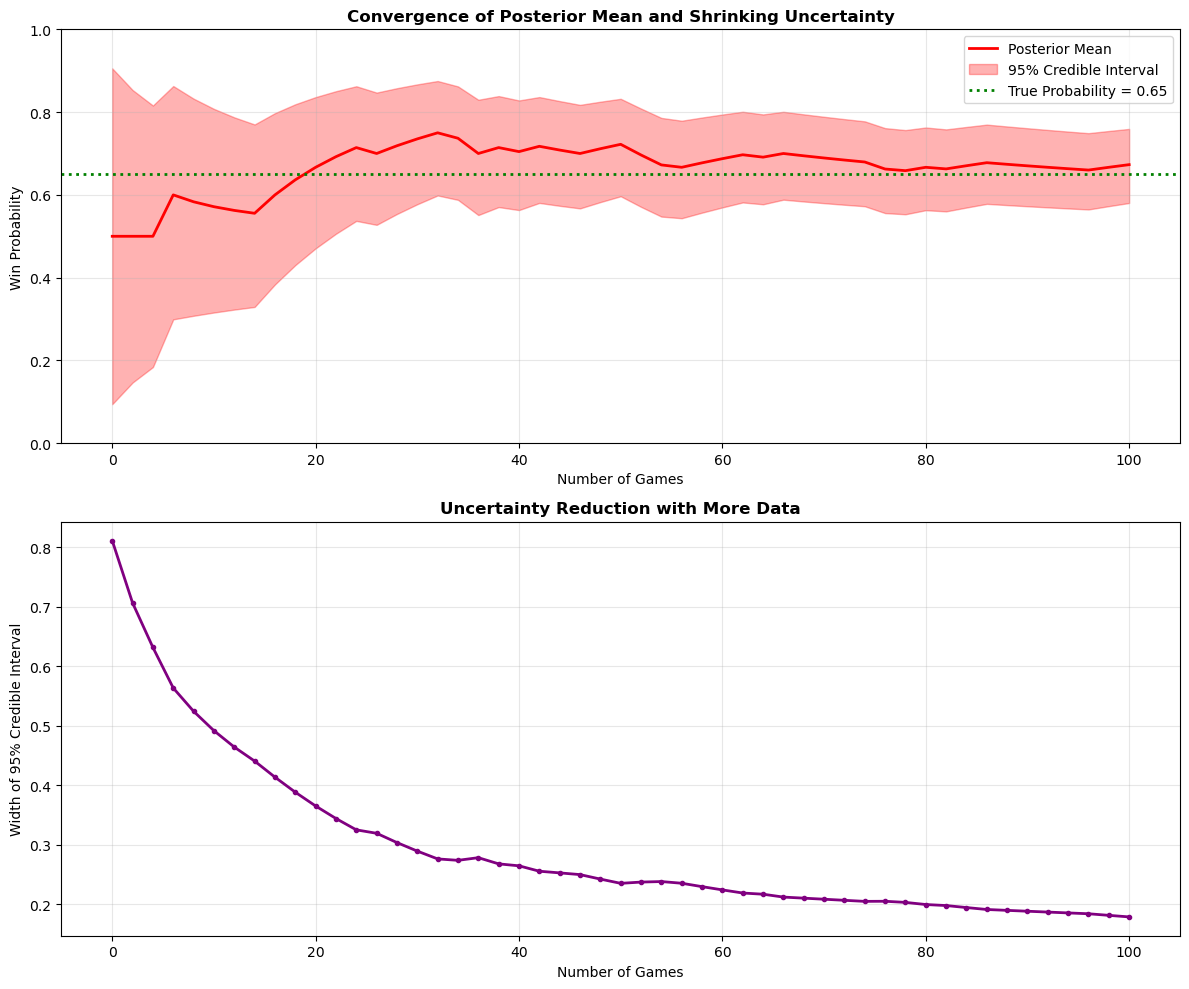

In [2]:
from lib.visualizations import plot_uncertainty_evolution
plot_uncertainty_evolution()

### 4. Hierarchical Relationship Modeling

Bayesian frameworks excel at **hierarchical modeling**, where parameters at one level are governed by hyperparameters at higher levels. This structure naturally captures complex dependencies and enables **information sharing** across related groups.

**Sports Example**: Modeling player performance across teams

- Individual player abilities (level 1)
- Team effects (level 2) 
- League-wide patterns (level 3)

Players with limited data benefit from team-level and league-level information, while stars with extensive data rely primarily on their individual track record. This **partial pooling** automatically determines the optimal balance.


In the problem mentioned above for app installs, intuitively there is an inherent hierarchical relationship between the mobile's operating systems, device types and software versions,etc. 

In the traditional machine learning context, this would be handled by encoding features like operating system(os), device type and software versions into categorical features. This hierarchical nature in their relationship does not get captured in the categorical features. Also,this results in a very sparse feature set for model training. Moreover, there will be situations where there just won't be enough data samples for certain categorical features - for instance, there won't be many nokia users and this leads us back to the cold start problem. 

All of these shortcomings can be addressed in the hierarchical representation shown below that can be captured by a hierarchical bayesian model with an appropriately defined model architecture, as will be discussed at length in the later sections. The visualization below captures the hierarchical nature - 


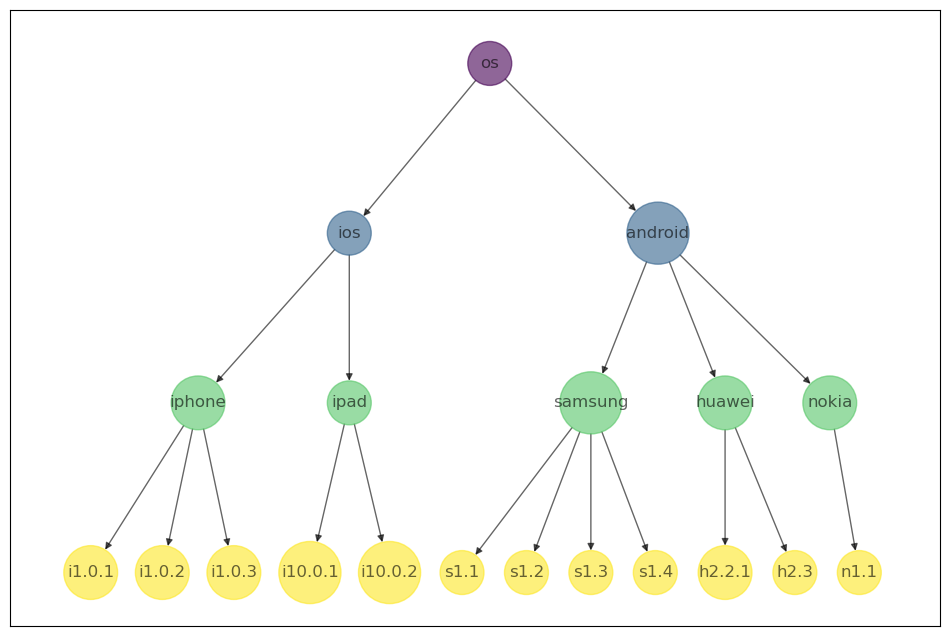

In [3]:
nodes_os =['ios','android']
nodes_device = ['iphone','ipad','samsung','huawei','nokia']
nodes_software_versions = ['i1.0.1','i1.0.2','i1.0.3','i10.0.1','i10.0.2', 's1.1','s1.2','s1.3','s1.4','h2.2.1','h2.3','n1.1']
nodes_list = ['os'] + nodes_os + nodes_device + nodes_software_versions
nodes_colors = [0] + [6]*len(nodes_os) + [14]*len(nodes_device) + [19]*len(nodes_software_versions)
os_edges = [('os','android'),('os','ios')]
device_edges = [('ios','iphone'),('ios','ipad'),('android','samsung'),('android','huawei'),('android','nokia')]
software_v_edges = [("iphone","i1.0.1"), ("iphone","i1.0.2"), ("iphone","i1.0.3"),
                   ("ipad","i10.0.1"),("ipad","i10.0.2"),
                   ("samsung","s1.1"), ("samsung","s1.2"), ("samsung","s1.3"), ("samsung","s1.4"),
                   ("huawei","h2.2.1"),("huawei","h2.3"),("nokia","n1.1")]
edges_list = os_edges + device_edges + software_v_edges

from lib.visualizations import HierarchicalGraphViz
HierarchicalGraphViz(nodes_list, edges_list, nodes_colors) 

## Challenges of the Bayesian Approach

### 1. Computational Complexity and Scalability

Most Bayesian models require **numerical approximation methods** like Markov Chain Monte Carlo (MCMC) since analytical solutions rarely exist for complex models. This introduces several challenges:

**Computational Cost**: MCMC methods can be orders of magnitude slower than optimization-based ML approaches. A model that fits in minutes with gradient descent might require hours or days with MCMC.

**Convergence Diagnostics**: Unlike optimization algorithms with clear stopping criteria, MCMC requires careful assessment of chain convergence through diagnostics like R̂ statistics, effective sample size, and visual inspection of trace plots.

**Scalability Issues**: Standard MCMC scales poorly with data size and model complexity. Large datasets require specialized techniques like variational inference, mini-batch sampling, or approximate methods that trade accuracy for speed.

### 2. Prior Specification and Sensitivity

**Subjective Prior Choice**: Selecting appropriate priors requires domain expertise and can significantly influence results, especially with limited data. Poor prior choices can:

- Introduce unintended bias
- Lead to overconfident or underconfident inferences
- Require extensive sensitivity analysis

**Prior-Data Conflict**: When priors strongly contradict data, interpretation becomes challenging. The model might require many observations to overcome poor priors, or might indicate fundamental modeling assumptions are wrong.

**Computational Priors**: Sometimes priors are chosen for computational convenience rather than substantive reasons, potentially compromising interpretability.

### 3. Model Validation and Evaluation Complexity

Unlike traditional ML with straightforward train/test splits, Bayesian model validation requires more sophisticated approaches:

**Leave-One-Out Cross-Validation (LOO-CV)**: While theoretically appealing, LOO-CV can be computationally expensive for complex models, requiring approximate methods like Pareto-smoothed importance sampling (PSIS-LOO).

**Posterior Predictive Checks**: Comparing observed data to posterior predictive distributions requires careful selection of test statistics and can miss certain types of model misspecification.

**Model Averaging Complexity**: When multiple plausible models exist, Bayesian model averaging provides principled combination but complicates interpretation and can mask important model differences.

### 4. Simulation-Based Model Development

A recommended Bayesian workflow involves **simulation-based calibration**:

1. **Understand the Data Generating Process**: Develop theoretical understanding of how your data arises
2. **Simulate Realistic Datasets**: Create synthetic data that closely resembles actual observations
3. **Iterative Model Development**: Build and refine models on simulated data where ground truth is known
4. **Validate on Real Data**: Apply refined models to actual data

This process, while thorough, is **time-intensive** and requires substantial domain expertise to create realistic simulations. Many practitioners skip these steps, potentially leading to poorly specified models.

### 5. Interpretability and Communication Challenges

**Probabilistic Thinking**: Bayesian results require probabilistic interpretation that can be challenging for stakeholders accustomed to point estimates. Explaining credible intervals, posterior distributions, and uncertainty quantification requires statistical education.

**Multiple Uncertainty Sources**: Bayesian models quantify various uncertainty types (parameter uncertainty, model uncertainty, prediction uncertainty), making communication complex.

**Decision Integration**: Converting posterior distributions into actionable business decisions requires careful consideration of loss functions and utility theory, adding complexity to the modeling process.

### 6. Software and Implementation Challenges

**Specialized Software**: Bayesian modeling often requires specialized tools (Stan, PyMC, JAGS) with steeper learning curves than traditional ML libraries.

**Debugging Difficulty**: Identifying problems in Bayesian models requires understanding of MCMC diagnostics, prior-likelihood interactions, and numerical stability issues that differ from standard debugging approaches.

**Reproducibility**: MCMC's random nature requires careful seed management and multiple chain analysis for reproducible results.

## Conclusion

Bayesian modeling offers a principled framework for incorporating prior knowledge, quantifying uncertainty, and making probabilistic predictions. Its advantages shine in scenarios with limited data, complex hierarchical structures, and high-stakes decisions where uncertainty quantification matters.

However, these benefits come with computational costs, implementation complexity, and communication challenges. The choice between Bayesian and traditional approaches depends on your specific context: data availability, computational resources, team expertise, and the value of uncertainty quantification in your decision-making process.

The key is recognizing that Bayesian modeling isn't universally superior—it's a powerful tool that excels in particular circumstances where its unique capabilities provide significant value over traditional alternatives.

---

[Part 2: Simulated Data Generation](../bayesian-modelling-part-2/index.html) →